In [2]:
import pandas as pd
import numpy as np
from forecast_logic import LoadForecaster
import os

def test_forecast():
    # 1. Setup paths
    model_dir = os.getcwd()
    forecaster = LoadForecaster(model_dir=model_dir)
    
    # 2. Load some real history to start from
    data_path = 'Integrated_Load_Data_Final.csv'
    if not os.path.exists(data_path):
        print(f"Data file {data_path} not found in {model_dir}")
        return
        
    df = pd.read_csv(data_path)
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True)
    
    history = df.sort_values('DATETIME').head(1002) # Use a chunk of history
    
    # 3. Create dummy weather forecast for 48 hours
    last_time = history['DATETIME'].max()
    future_times = pd.date_range(start=last_time + pd.Timedelta(minutes=15), periods=192, freq='15min')
    
    future_weather = pd.DataFrame({
        'DATETIME': future_times,
        'ACT_HEAT_INDEX': [history['ACT_HEAT_INDEX'].mean()] * 192,
        'ACT_HUMIDITY': [history['ACT_HUMIDITY'].mean()] * 192,
        'ACT_RAIN': [0] * 192,
        'ACT_TEMP': [history['ACT_TEMP'].mean()] * 192,
        'COOL_FACTOR': [history['COOL_FACTOR'].mean()] * 192,
        'Holiday_Ind': [0] * 192,
        'Event_Name': ['Normal Day'] * 192
    })
    
    # 4. Run forecast
    print("Starting 48-hour forecast...")
    predictions = forecaster.predict_48h(history, future_weather)
    
    print("Forecast completed!")
    print(predictions.head())
    print(predictions.tail())
    
    # 5. Summary check
    assert len(predictions) == 192, f"Expected 192 predictions, got {len(predictions)}"
    assert all(col in predictions.columns for col in ['DATETIME', 'P10', 'P50', 'P90'])
    print("✅ 48-hour forecast test passed.")

if __name__ == "__main__":
    test_forecast()


Starting 48-hour forecast...


D:\ARFA PROJECTS\Decodex Dalmia\Dalmia Round 1\model training\forecast_logic.py:79: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  prediction_times = pd.date_range(start=last_time + pd.Timedelta(minutes=15), periods=192, freq='15min')


Forecast completed!
             DATETIME          P10          P50          P90
0 2013-04-11 10:45:00  1320.408785  1319.111037  1319.869015
1 2013-04-11 11:00:00  1330.652100  1332.768486  1336.039583
2 2013-04-11 11:15:00  1344.071457  1344.006001  1344.133637
3 2013-04-11 11:30:00  1355.044984  1356.152788  1356.194498
4 2013-04-11 11:45:00  1365.368573  1368.814105  1365.797498
               DATETIME          P10          P50          P90
187 2013-04-13 09:30:00  1530.692840  1530.343165  1534.090489
188 2013-04-13 09:45:00  1528.665812  1528.342077  1532.144126
189 2013-04-13 10:00:00  1527.961042  1528.044004  1529.260045
190 2013-04-13 10:15:00  1528.981143  1528.421404  1529.285739
191 2013-04-13 10:30:00  1529.477396  1528.971212  1529.932732
✅ 48-hour forecast test passed.


In [1]:
import customtkinter as ctk
import pandas as pd
import os
from datetime import datetime
from forecast_logic import LoadForecaster

# Appearance and Theme
ctk.set_appearance_mode("Dark")
ctk.set_default_color_theme("blue")

class PredictGUI(ctk.CTk):
    def __init__(self):
        super().__init__()

        self.title("⚡ Dalmia Load Forecast - Manual Input")
        self.geometry("900x700")

        # Initialize Forecaster
        try:
            self.forecaster = LoadForecaster(model_dir=os.getcwd())
        except Exception as e:
            self.show_error(f"Initialization Error: {e}")
            return

        # UI Layout
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)

        self.setup_sidebar()
        self.setup_main_frame()

    def setup_sidebar(self):
        self.sidebar = ctk.CTkFrame(self, width=300, corner_radius=0)
        self.sidebar.grid(row=0, column=0, sticky="nsew", padx=10, pady=10)
        
        ctk.CTkLabel(self.sidebar, text="Forecast Parameters", font=ctk.CTkFont(size=20, weight="bold")).pack(pady=20)

        # Datetime
        ctk.CTkLabel(self.sidebar, text="Timestamp (YYYY-MM-DD HH:MM):").pack(padx=20, anchor="w")
        self.entry_datetime = ctk.CTkEntry(self.sidebar, placeholder_text="e.g. 2021-09-11 19:00")
        self.entry_datetime.insert(0, datetime.now().strftime("%Y-%m-%d %H:%M"))
        self.entry_datetime.pack(padx=20, pady=(0, 10), fill="x")

        # Temp Slider + Label
        ctk.CTkLabel(self.sidebar, text="Temperature (°C):").pack(padx=20, anchor="w")
        self.temp_slider = ctk.CTkSlider(self.sidebar, from_=10, to=50, command=self.update_temp_label)
        self.temp_slider.set(30)
        self.temp_slider.pack(padx=20, fill="x")
        self.temp_label = ctk.CTkLabel(self.sidebar, text="30.0 °C")
        self.temp_label.pack(padx=20, pady=(0, 10))

        # Humidity Slider + Label
        ctk.CTkLabel(self.sidebar, text="Humidity (%):").pack(padx=20, anchor="w")
        self.hum_slider = ctk.CTkSlider(self.sidebar, from_=0, to=100, command=self.update_hum_label)
        self.hum_slider.set(70)
        self.hum_slider.pack(padx=20, fill="x")
        self.hum_label = ctk.CTkLabel(self.sidebar, text="70 %")
        self.hum_label.pack(padx=20, pady=(0, 10))

        # Rain
        ctk.CTkLabel(self.sidebar, text="Rainfall Index:").pack(padx=20, anchor="w")
        self.entry_rain = ctk.CTkEntry(self.sidebar)
        self.entry_rain.insert(0, "0")
        self.entry_rain.pack(padx=20, pady=(0, 10), fill="x")

        # Event
        ctk.CTkLabel(self.sidebar, text="Event Name:").pack(padx=20, anchor="w")
        events = sorted(list(self.forecaster.le_event.classes_))
        self.event_dropdown = ctk.CTkOptionMenu(self.sidebar, values=events)
        if "Normal Day" in events:
            self.event_dropdown.set("Normal Day")
        self.event_dropdown.pack(padx=20, pady=(0, 10), fill="x")

        # Holiday Switch
        self.holiday_switch = ctk.CTkSwitch(self.sidebar, text="Holiday Indicator")
        self.holiday_switch.pack(padx=20, pady=10)

        # Predict Button
        self.predict_btn = ctk.CTkButton(self.sidebar, text="⚡ Get Prediction", command=self.run_prediction, 
                                        fg_color="#1f538d", hover_color="#14375e", font=ctk.CTkFont(size=14, weight="bold"))
        self.predict_btn.pack(padx=20, pady=30, fill="x")

    def setup_main_frame(self):
        self.main = ctk.CTkFrame(self)
        self.main.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)
        self.main.grid_columnconfigure(0, weight=1)

        ctk.CTkLabel(self.main, text="Forecast Results (MW)", font=ctk.CTkFont(size=24, weight="bold")).pack(pady=30)

        self.cards_frame = ctk.CTkFrame(self.main, fg_color="transparent")
        self.cards_frame.pack(fill="x", padx=20)
        self.cards_frame.grid_columnconfigure((0, 1, 2), weight=1)

        # P10 Card
        self.p10_card = self.create_result_card(self.cards_frame, "P10 (Lower Bound)", "---", "#3a7ebf", 0)
        # P50 Card
        self.p50_card = self.create_result_card(self.cards_frame, "P50 (Median Forecast)", "---", "#2fa572", 1)
        # P90 Card
        self.p90_card = self.create_result_card(self.cards_frame, "P90 (Upper Bound)", "---", "#df5234", 2)

        # Recommended Submission
        self.rec_frame = ctk.CTkFrame(self.main, border_width=2, border_color="#ff9800")
        self.rec_frame.pack(pady=50, padx=100, fill="x")
        ctk.CTkLabel(self.rec_frame, text="Recommended Submission (MW)", font=ctk.CTkFont(size=16)).pack(pady=(15, 5))
        self.rec_label = ctk.CTkLabel(self.rec_frame, text="---", font=ctk.CTkFont(size=36, weight="bold"), text_color="#ff9800")
        self.rec_label.pack(pady=(0, 15))

    def create_result_card(self, parent, title, value, color, col):
        card = ctk.CTkFrame(parent, border_width=1, border_color=color)
        card.grid(row=0, column=col, padx=10, pady=10, sticky="nsew")
        
        ctk.CTkLabel(card, text=title, font=ctk.CTkFont(size=12)).pack(pady=(10, 5))
        lbl = ctk.CTkLabel(card, text=value, font=ctk.CTkFont(size=24, weight="bold"), text_color=color)
        lbl.pack(pady=(0, 15))
        return lbl

    def update_temp_label(self, val):
        self.temp_label.configure(text=f"{val:.1f} °C")

    def update_hum_label(self, val):
        self.hum_label.configure(text=f"{int(val)} %")

    def run_prediction(self):
        try:
            # Gather inputs
            dt_str = self.entry_datetime.get()
            temp = self.temp_slider.get()
            hum = self.hum_slider.get()
            rain = float(self.entry_rain.get())
            event = self.event_dropdown.get()
            holiday = 1 if self.holiday_switch.get() else 0
            
            # Simple Heat Index & Cool Factor calculation for demo
            heat_index = temp + 0.1 * hum # Rough approx
            cool_factor = 25 - temp if temp < 25 else 0
            
            # Call Forecaster
            res = self.forecaster.predict_single(dt_str, temp, hum, rain, heat_index, cool_factor, event, holiday)
            
            # Update UI
            self.p10_card.configure(text=f"{res['P10']:.2f}")
            self.p50_card.configure(text=f"{res['P50']:.2f}")
            self.p90_card.configure(text=f"{res['P90']:.2f}")
            
            rec = res['P90'] * 0.95
            self.rec_label.configure(text=f"{rec:.2f}")

        except Exception as e:
            self.show_error(f"Prediction Failed: {e}")

    def show_error(self, message):
        error_win = ctk.CTkToplevel(self)
        error_win.title("Error")
        error_win.geometry("400x200")
        ctk.CTkLabel(error_win, text=message, wraplength=350).pack(expand=True, padx=20, pady=20)
        ctk.CTkButton(error_win, text="OK", command=error_win.destroy).pack(pady=10)

if __name__ == "__main__":
    app = PredictGUI()
    app.mainloop()


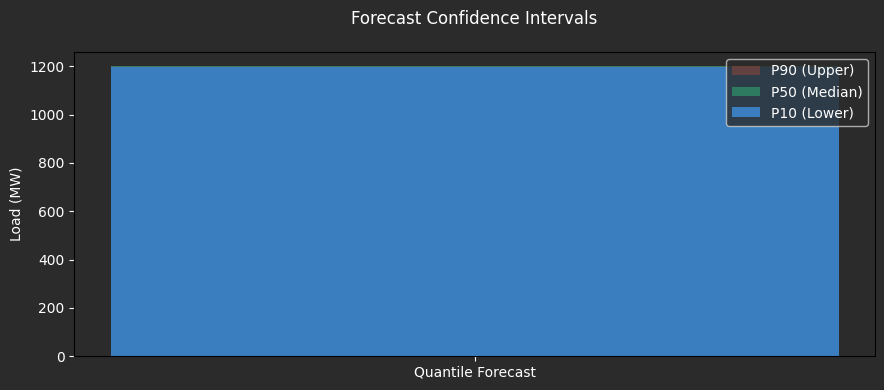

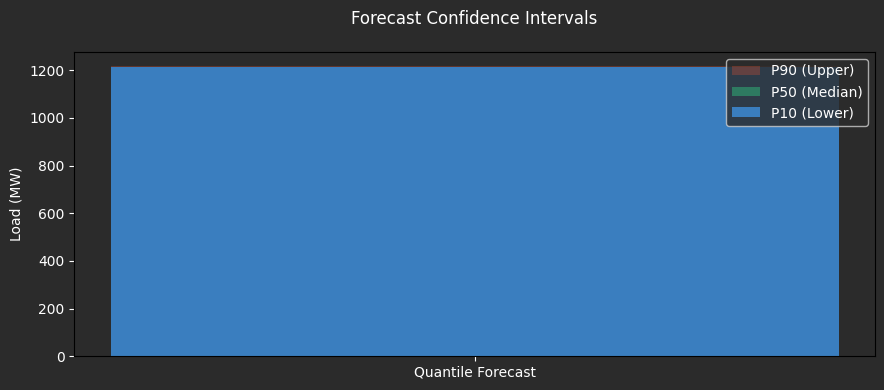

In [1]:
import customtkinter as ctk
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from datetime import datetime
from forecast_logic import LoadForecaster

# Appearance and Theme
ctk.set_appearance_mode("Dark")
ctk.set_default_color_theme("blue")

class PredictGUI(ctk.CTk):
    def __init__(self):
        super().__init__()

        self.title("⚡ Dalmia Load Forecast v2")
        self.geometry("1000x800")

        # Initialize Forecaster
        try:
            self.forecaster = LoadForecaster(model_dir=os.getcwd())
        except Exception as e:
            self.show_error(f"Initialization Error: {e}")
            return

        # UI Layout
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)

        self.setup_sidebar()
        self.setup_main_frame()

    def setup_sidebar(self):
        self.sidebar = ctk.CTkScrollableFrame(self, width=320, corner_radius=0)
        self.sidebar.grid(row=0, column=0, sticky="nsew", padx=10, pady=10)
        
        ctk.CTkLabel(self.sidebar, text="Forecast Parameters", font=ctk.CTkFont(size=20, weight="bold")).pack(pady=20)

        # Datetime
        self.create_input_field("Timestamp (YYYY-MM-DD HH:MM):", "entry_datetime", datetime.now().strftime("%Y-%m-%d %H:%M"))

        # Weather Inputs (Numerical)
        self.create_input_field("Temperature (°C):", "entry_temp", "30.0")
        self.create_input_field("Humidity (%):", "entry_hum", "70.0")
        self.create_input_field("Heat Index:", "entry_heat", "32.0")
        self.create_input_field("Cool Factor:", "entry_cool", "0.0")
        self.create_input_field("Rainfall Index:", "entry_rain", "0.0")

        # Grid Constants
        self.create_input_field("Recent Load (MW) [Baseline]:", "entry_base_load", "1200")

        # Event
        ctk.CTkLabel(self.sidebar, text="Event Name:").pack(padx=20, anchor="w")
        events = sorted(list(self.forecaster.le_event.classes_))
        self.event_dropdown = ctk.CTkOptionMenu(self.sidebar, values=events)
        if "Normal Day" in events:
            self.event_dropdown.set("Normal Day")
        self.event_dropdown.pack(padx=20, pady=(0, 10), fill="x")

        # Holiday Switch
        self.holiday_switch = ctk.CTkSwitch(self.sidebar, text="Holiday Indicator")
        self.holiday_switch.pack(padx=20, pady=10)

        # Predict Button
        self.predict_btn = ctk.CTkButton(self.sidebar, text="⚡ Get Prediction & Analysis", command=self.run_prediction, 
                                        fg_color="#1f538d", hover_color="#14375e", font=ctk.CTkFont(size=14, weight="bold"))
        self.predict_btn.pack(padx=20, pady=30, fill="x")

    def create_input_field(self, label, attr_name, default_val):
        ctk.CTkLabel(self.sidebar, text=label).pack(padx=20, anchor="w")
        entry = ctk.CTkEntry(self.sidebar)
        entry.insert(0, default_val)
        entry.pack(padx=20, pady=(0, 10), fill="x")
        setattr(self, attr_name, entry)

    def setup_main_frame(self):
        self.main = ctk.CTkFrame(self)
        self.main.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)
        self.main.grid_columnconfigure(0, weight=1)
        self.main.grid_rowconfigure(3, weight=1)

        ctk.CTkLabel(self.main, text="Forecast Insight", font=ctk.CTkFont(size=24, weight="bold")).pack(pady=20)

        # Top Results (Cards)
        self.cards_frame = ctk.CTkFrame(self.main, fg_color="transparent")
        self.cards_frame.pack(fill="x", padx=20)
        self.cards_frame.grid_columnconfigure((0, 1, 2), weight=1)

        self.p10_card = self.create_result_card(self.cards_frame, "P10 (Lower)", "---", "#3a7ebf", 0)
        self.p50_card = self.create_result_card(self.cards_frame, "P50 (Median)", "---", "#2fa572", 1)
        self.p90_card = self.create_result_card(self.cards_frame, "P90 (Upper)", "---", "#df5234", 2)

        # Chart Container
        self.chart_frame = ctk.CTkFrame(self.main, border_width=1)
        self.chart_frame.pack(fill="both", expand=True, padx=20, pady=20)
        self.chart_label = ctk.CTkLabel(self.chart_frame, text="Prediction range chart will appear here...")
        self.chart_label.pack(expand=True)

        # Recommended Bar
        self.rec_frame = ctk.CTkFrame(self.main, border_width=2, border_color="#ff9800")
        self.rec_frame.pack(pady=(0, 20), padx=50, fill="x")
        ctk.CTkLabel(self.rec_frame, text="Recommended Load Submission (MW)", font=ctk.CTkFont(size=14)).pack(pady=(10, 0))
        self.rec_label = ctk.CTkLabel(self.rec_frame, text="---", font=ctk.CTkFont(size=28, weight="bold"), text_color="#ff9800")
        self.rec_label.pack(pady=(0, 10))

    def create_result_card(self, parent, title, value, color, col, unit="MW"):
        card = ctk.CTkFrame(parent, border_width=1, border_color=color)
        card.grid(row=0, column=col, padx=5, pady=5, sticky="nsew")
        ctk.CTkLabel(card, text=title, font=ctk.CTkFont(size=11)).pack(pady=(10, 2))
        lbl = ctk.CTkLabel(card, text=value, font=ctk.CTkFont(size=20, weight="bold"), text_color=color)
        lbl.pack(pady=(0, 1))
        ctk.CTkLabel(card, text=unit, font=ctk.CTkFont(size=10)).pack(pady=(0, 10))
        return lbl

    def run_prediction(self):
        try:
            # Gather inputs
            dt_str = self.entry_datetime.get()
            temp = float(self.entry_temp.get())
            hum = float(self.entry_hum.get())
            heat = float(self.entry_heat.get())
            cool = float(self.entry_cool.get())
            rain = float(self.entry_rain.get())
            base_load = float(self.entry_base_load.get())
            event = self.event_dropdown.get()
            holiday = 1 if self.holiday_switch.get() else 0
            
            # Prediction
            res = self.forecaster.predict_single(dt_str, temp, hum, rain, heat, cool, event, holiday, base_load=base_load)
            
            # Update Cards
            self.p10_card.configure(text=f"{res['P10']:.2f}")
            self.p50_card.configure(text=f"{res['P50']:.2f}")
            self.p90_card.configure(text=f"{res['P90']:.2f}")
            
            rec = res['P90'] * 0.95
            self.rec_label.configure(text=f"{rec:.2f} MW")

            # Plotting
            self.update_plot(res['P10'], res['P50'], res['P90'])

        except Exception as e:
            self.show_error(f"Analysis Failed: {e}")

    def update_plot(self, p10, p50, p90):
        # Clear frame
        for widget in self.chart_frame.winfo_children():
            widget.destroy()

        fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
        fig.patch.set_facecolor('#2b2b2b')
        ax.set_facecolor('#2b2b2b')

        labels = ['Quantile Forecast']
        ax.bar(labels, [p90], color='#df5234', alpha=0.3, label='P90 (Upper)')
        ax.bar(labels, [p50], color='#2fa572', alpha=0.6, label='P50 (Median)')
        ax.bar(labels, [p10], color='#3a7ebf', alpha=1.0, label='P10 (Lower)')

        ax.set_ylabel('Load (MW)', color='white')
        ax.tick_params(axis='y', colors='white')
        ax.tick_params(axis='x', colors='white')
        ax.set_title('Forecast Confidence Intervals', color='white', pad=20)
        ax.legend(facecolor='#2b2b2b', labelcolor='white')
        
        plt.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=self.chart_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill="both", expand=True)

    def show_error(self, message):
        error_win = ctk.CTkToplevel(self)
        error_win.title("Error")
        error_win.geometry("400x200")
        ctk.CTkLabel(error_win, text=message, wraplength=350).pack(expand=True, padx=20, pady=20)
        ctk.CTkButton(error_win, text="OK", command=error_win.destroy).pack(pady=10)

if __name__ == "__main__":
    app = PredictGUI()
    app.mainloop()


In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
import pickle
from sklearn.model_selection import train_test_split

# 1. Load Data
data_path = 'Integrated_Load_Data_Final.csv'
if not os.path.exists(data_path):
    print(f"Data file {data_path} not found.")
    exit(1)

df = pd.read_csv(data_path)
df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True)

# 2. Re-calculate engineered features (copying from forecast_logic.py)
def engineer_features(df):
    df = df.copy()
    # Basic Time Features
    df['hour'] = df['DATETIME'].dt.hour
    df['minute'] = df['DATETIME'].dt.minute
    df['day_of_week'] = df['DATETIME'].dt.dayofweek
    df['day_of_month'] = df['DATETIME'].dt.day
    df['month'] = df['DATETIME'].dt.month
    df['year'] = df['DATETIME'].dt.year
    df['week_of_year'] = df['DATETIME'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['DATETIME'].dt.quarter
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Cyclic Transformations
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['month_sin'] = np.sin(2 * np.pi * (df['month']-1)/12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month']-1)/12)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
    
    # Interactions
    df['temp_humidity'] = df['ACT_TEMP'] * df['ACT_HUMIDITY']
    df['heat_index_sq'] = df['ACT_HEAT_INDEX']**2
    df['cool_factor_sq'] = df['COOL_FACTOR']**2
    
    # Label Encoding (assuming existing label_encoder_event.pkl is present)
    with open('label_encoder_event.pkl', 'rb') as f:
        le = pickle.load(f)
    
    # Ensure all event names are covered
    df['Event_Encoded'] = le.transform(df['Event_Name'])
    return df

df = engineer_features(df)

# 3. Define Pure Feature Columns (NO LAGS)
feature_cols = [
    'ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR', 
    'Holiday_Ind', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 
    'year', 'week_of_year', 'quarter', 'time_slot', 'is_weekend', 
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 
    'Event_Encoded', 'temp_humidity', 'heat_index_sq', 'cool_factor_sq'
]

# 4. Train Models
X = df[feature_cols]
y = df['LOAD']

params = {
    'objective': 'quantile',
    'metric': 'quantile',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

print("Training Pure Feature Models (no lags)...")
for quantile, label in zip([0.1, 0.5, 0.9], ['P10', 'P50', 'P90']):
    print(f"Training {label}...")
    q_params = params.copy()
    q_params['alpha'] = quantile
    
    dtrain = lgb.Dataset(X, label=y)
    model = lgb.train(q_params, dtrain, num_boost_round=100) # Simple training for demo
    model.save_model(f'lgbm_quantile_{label}.txt')

# 5. Save new feature columns
with open('feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print("Successfully trained pure feature models and updated feature_columns.txt")


Training Pure Feature Models (no lags)...
Training P10...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2276
[LightGBM] [Info] Number of data points in the train set: 283391, number of used features: 26
[LightGBM] [Info] Start training from score 883.000000
Training P50...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2276
[LightGBM] [Info] Number of data points in the train set: 283391, number of used features: 26
[LightGBM] [Info] Start training from score 1229.000000
Training P90...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011793 seconds.
You can set `force_row_wise=true` to remove the ove

In [3]:
import customtkinter as ctk
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from datetime import datetime
from forecast_logic import LoadForecaster

# Appearance and Theme
ctk.set_appearance_mode("Dark")
ctk.set_default_color_theme("blue")

class PredictGUI(ctk.CTk):
    def __init__(self):
        super().__init__()

        self.title("⚡ Dalmia Load Forecast v2")
        self.geometry("1000x800")

        # Initialize Forecaster
        try:
            self.forecaster = LoadForecaster(model_dir=os.getcwd())
        except Exception as e:
            self.show_error(f"Initialization Error: {e}")
            return

        # UI Layout
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)

        self.setup_sidebar()
        self.setup_main_frame()

    def setup_sidebar(self):
        self.sidebar = ctk.CTkScrollableFrame(self, width=320, corner_radius=0)
        self.sidebar.grid(row=0, column=0, sticky="nsew", padx=10, pady=10)
        
        ctk.CTkLabel(self.sidebar, text="Forecast Parameters", font=ctk.CTkFont(size=20, weight="bold")).pack(pady=20)

        # Datetime
        self.create_input_field("Timestamp (YYYY-MM-DD HH:MM):", "entry_datetime", datetime.now().strftime("%Y-%m-%d %H:%M"))

        # Weather Inputs (Numerical)
        self.create_input_field("Temperature (°C):", "entry_temp", "30.0")
        self.create_input_field("Humidity (%):", "entry_hum", "71.0")
        self.create_input_field("Heat Index:", "entry_heat", "32.0")
        self.create_input_field("Cool Factor:", "entry_cool", "0.0")
        self.create_input_field("Rainfall Index:", "entry_rain", "0.0")

        # Event
        ctk.CTkLabel(self.sidebar, text="Event Name:").pack(padx=20, anchor="w")
        events = sorted(list(self.forecaster.le_event.classes_))
        self.event_dropdown = ctk.CTkOptionMenu(self.sidebar, values=events)
        if "Normal Day" in events:
            self.event_dropdown.set("Normal Day")
        self.event_dropdown.pack(padx=20, pady=(0, 10), fill="x")

        # Holiday Switch
        self.holiday_switch = ctk.CTkSwitch(self.sidebar, text="Holiday Indicator")
        self.holiday_switch.pack(padx=20, pady=10)

        # Predict Button
        self.predict_btn = ctk.CTkButton(self.sidebar, text="⚡ Get Prediction & Analysis", command=self.run_prediction, 
                                        fg_color="#1f538d", hover_color="#14375e", font=ctk.CTkFont(size=14, weight="bold"))
        self.predict_btn.pack(padx=20, pady=30, fill="x")

    def create_input_field(self, label, attr_name, default_val):
        ctk.CTkLabel(self.sidebar, text=label).pack(padx=20, anchor="w")
        entry = ctk.CTkEntry(self.sidebar)
        entry.insert(0, default_val)
        entry.pack(padx=20, pady=(0, 10), fill="x")
        setattr(self, attr_name, entry)

    def setup_main_frame(self):
        self.main = ctk.CTkFrame(self)
        self.main.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)
        self.main.grid_columnconfigure(0, weight=1)
        self.main.grid_rowconfigure(3, weight=1)

        ctk.CTkLabel(self.main, text="Forecast Insight", font=ctk.CTkFont(size=24, weight="bold")).pack(pady=20)

        # Top Results (Cards)
        self.cards_frame = ctk.CTkFrame(self.main, fg_color="transparent")
        self.cards_frame.pack(fill="x", padx=20)
        self.cards_frame.grid_columnconfigure((0, 1, 2), weight=1)

        self.p10_card = self.create_result_card(self.cards_frame, "P10 (Lower)", "---", "#3a7ebf", 0)
        self.p50_card = self.create_result_card(self.cards_frame, "P50 (Median)", "---", "#2fa572", 1)
        self.p90_card = self.create_result_card(self.cards_frame, "P90 (Upper)", "---", "#df5234", 2)

        # Chart Container
        self.chart_frame = ctk.CTkFrame(self.main, border_width=1)
        self.chart_frame.pack(fill="both", expand=True, padx=20, pady=20)
        self.chart_label = ctk.CTkLabel(self.chart_frame, text="Prediction range chart will appear here...")
        self.chart_label.pack(expand=True)

        # Recommended Bar
        self.rec_frame = ctk.CTkFrame(self.main, border_width=2, border_color="#ff9800")
        self.rec_frame.pack(pady=(0, 20), padx=50, fill="x")
        ctk.CTkLabel(self.rec_frame, text="Recommended Load Submission (MW)", font=ctk.CTkFont(size=14)).pack(pady=(10, 0))
        self.rec_label = ctk.CTkLabel(self.rec_frame, text="---", font=ctk.CTkFont(size=28, weight="bold"), text_color="#ff9800")
        self.rec_label.pack(pady=(0, 10))

    def create_result_card(self, parent, title, value, color, col, unit="MW"):
        card = ctk.CTkFrame(parent, border_width=1, border_color=color)
        card.grid(row=0, column=col, padx=5, pady=5, sticky="nsew")
        ctk.CTkLabel(card, text=title, font=ctk.CTkFont(size=11)).pack(pady=(10, 2))
        lbl = ctk.CTkLabel(card, text=value, font=ctk.CTkFont(size=20, weight="bold"), text_color=color)
        lbl.pack(pady=(0, 1))
        ctk.CTkLabel(card, text=unit, font=ctk.CTkFont(size=10)).pack(pady=(0, 10))
        return lbl

    def run_prediction(self):
        try:
            # Gather inputs
            dt_str = self.entry_datetime.get()
            temp = float(self.entry_temp.get())
            hum = float(self.entry_hum.get())
            heat = float(self.entry_heat.get())
            cool = float(self.entry_cool.get())
            rain = float(self.entry_rain.get())
            event = self.event_dropdown.get()
            holiday = 1 if self.holiday_switch.get() else 0
            
            # Prediction
            res = self.forecaster.predict_single(dt_str, temp, hum, rain, heat, cool, event, holiday)
            
            # Update Cards
            self.p10_card.configure(text=f"{res['P10']:.2f}")
            self.p50_card.configure(text=f"{res['P50']:.2f}")
            self.p90_card.configure(text=f"{res['P90']:.2f}")
            
            rec = res['P90'] * 0.95
            self.rec_label.configure(text=f"{rec:.2f} MW")

            # Plotting
            self.update_plot(res['P10'], res['P50'], res['P90'])

        except Exception as e:
            self.show_error(f"Analysis Failed: {e}")

    def update_plot(self, p10, p50, p90):
        # Clear frame
        for widget in self.chart_frame.winfo_children():
            widget.destroy()

        fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
        fig.patch.set_facecolor('#2b2b2b')
        ax.set_facecolor('#2b2b2b')

        labels = ['Quantile Forecast']
        ax.bar(labels, [p90], color='#df5234', alpha=0.3, label='P90 (Upper)')
        ax.bar(labels, [p50], color='#2fa572', alpha=0.6, label='P50 (Median)')
        ax.bar(labels, [p10], color='#3a7ebf', alpha=1.0, label='P10 (Lower)')

        ax.set_ylabel('Load (MW)', color='white')
        ax.tick_params(axis='y', colors='white')
        ax.tick_params(axis='x', colors='white')
        ax.set_title('Forecast Confidence Intervals', color='white', pad=20)
        ax.legend(facecolor='#2b2b2b', labelcolor='white')
        
        plt.tight_layout()

        canvas = FigureCanvasTkAgg(fig, master=self.chart_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill="both", expand=True)

    def show_error(self, message):
        error_win = ctk.CTkToplevel(self)
        error_win.title("Error")
        error_win.geometry("400x200")
        ctk.CTkLabel(error_win, text=message, wraplength=350).pack(expand=True, padx=20, pady=20)
        ctk.CTkButton(error_win, text="OK", command=error_win.destroy).pack(pady=10)

if __name__ == "__main__":
    app = PredictGUI()
    app.mainloop()


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
import pickle
from sklearn.model_selection import train_test_split

# 1. Load Data
data_path = 'Integrated_Load_Data_Final.csv'
if not os.path.exists(data_path):
    print(f"Data file {data_path} not found.")
    exit(1)

df = pd.read_csv(data_path)
df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True)

# 2. Re-calculate engineered features (copying from forecast_logic.py)
def engineer_features(df):
    df = df.copy()
    # Basic Time Features
    df['hour'] = df['DATETIME'].dt.hour
    df['minute'] = df['DATETIME'].dt.minute
    df['day_of_week'] = df['DATETIME'].dt.dayofweek
    df['day_of_month'] = df['DATETIME'].dt.day
    df['month'] = df['DATETIME'].dt.month
    df['year'] = df['DATETIME'].dt.year
    df['week_of_year'] = df['DATETIME'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['DATETIME'].dt.quarter
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Cyclic Transformations
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['month_sin'] = np.sin(2 * np.pi * (df['month']-1)/12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month']-1)/12)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
    
    # Interactions
    df['temp_humidity'] = df['ACT_TEMP'] * df['ACT_HUMIDITY']
    df['heat_index_sq'] = df['ACT_HEAT_INDEX']**2
    df['cool_factor_sq'] = df['COOL_FACTOR']**2
    
    # Label Encoding (assuming existing label_encoder_event.pkl is present)
    with open('label_encoder_event.pkl', 'rb') as f:
        le = pickle.load(f)
    
    # Ensure all event names are covered
    df['Event_Encoded'] = le.transform(df['Event_Name'])
    return df

df = engineer_features(df)

# 3. Define Pure Feature Columns (NO LAGS)
feature_cols = [
    'ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR', 
    'Holiday_Ind', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 
    'year', 'week_of_year', 'quarter', 'time_slot', 'is_weekend', 
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 
    'Event_Encoded', 'temp_humidity', 'heat_index_sq', 'cool_factor_sq'
]

# 4. Train Models
X = df[feature_cols]
y = df['LOAD']

params = {
    'objective': 'quantile',
    'metric': 'quantile',
    'boosting_type': 'gbdt',
    'num_leaves': 64,         # Increased for more complexity
    'learning_rate': 0.03,    # Lowered for more precise learning
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

print("Running Optimized Training (1000 rounds)...")
for quantile, label in zip([0.1, 0.5, 0.9], ['P10', 'P50', 'P90']):
    print(f"Training {label} on 280k+ samples...")
    q_params = params.copy()
    q_params['alpha'] = quantile
    
    dtrain = lgb.Dataset(X, label=y)
    # Increased rounds to 1000 for deep optimization
    model = lgb.train(q_params, dtrain, num_boost_round=1000) 
    model.save_model(f'lgbm_quantile_{label}.txt')

# 5. Save new feature columns
with open('feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print("Successfully trained pure feature models and updated feature_columns.txt")


Running Optimized Training (1000 rounds)...
Training P10 on 280k+ samples...
Training P50 on 280k+ samples...
Training P90 on 280k+ samples...
Successfully trained pure feature models and updated feature_columns.txt


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
import pickle
from sklearn.model_selection import train_test_split

# 1. Load Data
data_path = 'Integrated_Load_Data_Final.csv'
if not os.path.exists(data_path):
    print(f"Data file {data_path} not found.")
    exit(1)

df = pd.read_csv(data_path)
df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='mixed', dayfirst=True)

# 2. Re-calculate engineered features (copying from forecast_logic.py)
def engineer_features(df):
    df = df.copy()
    # Basic Time Features
    df['hour'] = df['DATETIME'].dt.hour
    df['minute'] = df['DATETIME'].dt.minute
    df['day_of_week'] = df['DATETIME'].dt.dayofweek
    df['day_of_month'] = df['DATETIME'].dt.day
    df['month'] = df['DATETIME'].dt.month
    df['year'] = df['DATETIME'].dt.year
    df['week_of_year'] = df['DATETIME'].dt.isocalendar().week.astype(int)
    df['quarter'] = df['DATETIME'].dt.quarter
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Cyclic Transformations
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['month_sin'] = np.sin(2 * np.pi * (df['month']-1)/12)
    df['month_cos'] = np.cos(2 * np.pi * (df['month']-1)/12)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
    
    # Interactions
    df['temp_humidity'] = df['ACT_TEMP'] * df['ACT_HUMIDITY']
    df['heat_index_sq'] = df['ACT_HEAT_INDEX']**2
    df['cool_factor_sq'] = df['COOL_FACTOR']**2
    
    # Label Encoding (assuming existing label_encoder_event.pkl is present)
    with open('label_encoder_event.pkl', 'rb') as f:
        le = pickle.load(f)
    
    # Ensure all event names are covered
    df['Event_Encoded'] = le.transform(df['Event_Name'])
    return df

df = engineer_features(df)

# 3. Define Pure Feature Columns (NO LAGS)
feature_cols = [
    'ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR', 
    'Holiday_Ind', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 
    'year', 'week_of_year', 'quarter', 'time_slot', 'is_weekend', 
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 
    'Event_Encoded', 'temp_humidity', 'heat_index_sq', 'cool_factor_sq'
]

# 4. Train Models
X = df[feature_cols]
y = df['LOAD']

params = {
    'objective': 'quantile',
    'metric': 'quantile',
    'boosting_type': 'gbdt',
    'num_leaves': 128,        # Doubled for maximum detail
    'learning_rate': 0.02,    # Slower learning for better plateauing
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

print("Running Maximum Optimization (2000 rounds)...")
for quantile, label in zip([0.1, 0.5, 0.9], ['P10', 'P50', 'P90']):
    print(f"Deep Training {label} on 280k+ samples...")
    q_params = params.copy()
    q_params['alpha'] = quantile
    
    dtrain = lgb.Dataset(X, label=y)
    # Increased rounds to 2000 for maximum possible detail
    model = lgb.train(q_params, dtrain, num_boost_round=2000) 
    model.save_model(f'lgbm_quantile_{label}.txt')

# 5. Save new feature columns
with open('feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")

print("Successfully trained pure feature models and updated feature_columns.txt")


In [2]:
"""
Full Test Data Analysis Script
Merges Electric Load Test + External Factor Test CSVs,
runs them through the trained model, and computes performance metrics.
"""

import pandas as pd
import numpy as np
import pickle
import lightgbm as lgb
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for saving

# ── 0. Config ──────────────────────────────────────────────────────────────────
MODEL_DIR = r"d:\ARFA PROJECTS\Decodex Dalmia\Dalmia Round 1\model training"
LOAD_CSV  = os.path.join(MODEL_DIR, "Electric_Load_Data_Test.csv")
EXT_CSV   = os.path.join(MODEL_DIR, "External_Factor_Data_Test.csv")
OUTPUT_CSV = os.path.join(MODEL_DIR, "test_predictions_analysis.csv")
CHART_PATH = os.path.join(MODEL_DIR, "test_analysis_chart.png")

# ── 1. Load CSVs ───────────────────────────────────────────────────────────────
print("Loading test data...")
load_df = pd.read_csv(LOAD_CSV)
ext_df  = pd.read_csv(EXT_CSV)

# ── 2. Parse & Merge ───────────────────────────────────────────────────────────
def parse_datetime(df):
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='%d%b%Y:%H:%M:%S', dayfirst=True)
    return df

load_df = parse_datetime(load_df)
ext_df  = parse_datetime(ext_df)

df = pd.merge(load_df, ext_df, on='DATETIME', how='inner')
print(f"Merged dataset: {len(df)} rows from {df['DATETIME'].min()} to {df['DATETIME'].max()}")

# ── 3. Feature Engineering ─────────────────────────────────────────────────────
df['hour']         = df['DATETIME'].dt.hour
df['minute']       = df['DATETIME'].dt.minute
df['day_of_week']  = df['DATETIME'].dt.dayofweek
df['day_of_month'] = df['DATETIME'].dt.day
df['month']        = df['DATETIME'].dt.month
df['year']         = df['DATETIME'].dt.year
df['week_of_year'] = df['DATETIME'].dt.isocalendar().week.astype(int)
df['quarter']      = df['DATETIME'].dt.quarter
df['time_slot']    = df['hour'] * 4 + df['minute'] // 15
df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)

# Cyclic
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Interactions
df['temp_humidity']  = df['ACT_TEMP'] * df['ACT_HUMIDITY']
df['heat_index_sq']  = df['ACT_HEAT_INDEX'] ** 2
df['cool_factor_sq'] = df['COOL_FACTOR'] ** 2

# Event & Holiday (default for test — no event data in test CSVs)
df['Holiday_Ind']    = 0
with open(os.path.join(MODEL_DIR, 'label_encoder_event.pkl'), 'rb') as f:
    le = pickle.load(f)
default_event = 'Normal Day' if 'Normal Day' in le.classes_ else le.classes_[0]
df['Event_Encoded'] = le.transform([default_event] * len(df))

# ── 4. Load feature list & Models ─────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, 'feature_columns.txt')) as f:
    feature_cols = [l.strip() for l in f.readlines()]

models = {}
for q in ['P10', 'P50', 'P90']:
    models[q] = lgb.Booster(model_file=os.path.join(MODEL_DIR, f'lgbm_quantile_{q}.txt'))

print(f"Loaded models with {len(feature_cols)} features: {feature_cols[:5]}...")

# ── 5. Predict ─────────────────────────────────────────────────────────────────
X = df[feature_cols]
df['P10'] = models['P10'].predict(X)
df['P50'] = models['P50'].predict(X)
df['P90'] = models['P90'].predict(X)

# ── 6. Metrics ─────────────────────────────────────────────────────────────────
actual = df['LOAD']
p50    = df['P50']

mae  = np.mean(np.abs(actual - p50))
rmse = np.sqrt(np.mean((actual - p50) ** 2))
mape = np.mean(np.abs((actual - p50) / actual)) * 100
r2   = 1 - (np.sum((actual - p50)**2) / np.sum((actual - actual.mean())**2))

# Capture Rate: what % of actuals fall within P10-P90
in_range = ((actual >= df['P10']) & (actual <= df['P90'])).mean() * 100

print("\n" + "="*55)
print("       FULL TEST SET MODEL PERFORMANCE REPORT")
print("="*55)
print(f"  Total Rows Evaluated : {len(df):,}")
print(f"  Date Range           : {df['DATETIME'].min().date()} → {df['DATETIME'].max().date()}")
print("-"*55)
print(f"  MAE  (P50 vs Actual) : {mae:.2f} MW")
print(f"  RMSE (P50 vs Actual) : {rmse:.2f} MW")
print(f"  MAPE (P50 vs Actual) : {mape:.2f} %")
print(f"  R²   (P50 vs Actual) : {r2:.4f}")
print(f"  P10-P90 Capture Rate : {in_range:.1f} %")
print("="*55)

# ── 7. Per-Hour Analysis ───────────────────────────────────────────────────────
df['abs_error'] = np.abs(actual - p50)
hourly = df.groupby('hour')['abs_error'].mean().reset_index()
hourly.columns = ['Hour', 'MAE_MW']

print("\n  Hourly MAE Summary:")
print(hourly.to_string(index=False))

# ── 8. Save Results ───────────────────────────────────────────────────────────
out = df[['DATETIME', 'LOAD', 'P10', 'P50', 'P90', 'abs_error']].copy()
out.columns = ['DATETIME', 'Actual_MW', 'P10_MW', 'P50_MW', 'P90_MW', 'Error_MW']
out.to_csv(OUTPUT_CSV, index=False)
print(f"\n  Results saved → {OUTPUT_CSV}")

# ── 9. Chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle("Full Test Set Analysis — Load Forecast Model", fontsize=16, fontweight='bold')

# 9a. Actual vs P50 (sample first 7 days)
sample = df.head(7 * 96)
axes[0].plot(sample['DATETIME'], sample['LOAD'], label='Actual',  color='white',    linewidth=1.5, alpha=0.9)
axes[0].plot(sample['DATETIME'], sample['P50'],  label='P50',     color='#2fa572',  linewidth=1.2)
axes[0].fill_between(sample['DATETIME'], sample['P10'], sample['P90'],
                     alpha=0.25, color='#3a7ebf', label='P10–P90 Range')
axes[0].set_facecolor('#1a1a2e')
axes[0].set_title("Actual vs Predicted (First 7 Days)", color='white')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='#16213e', labelcolor='white')
axes[0].spines['bottom'].set_color('#444')
axes[0].spines['left'].set_color('#444')

# 9b. Error Distribution
axes[1].hist(df['abs_error'], bins=80, color='#ffb300', edgecolor='none', alpha=0.9)
axes[1].axvline(mae, color='#df5234', linestyle='--', label=f'Mean Error = {mae:.1f} MW')
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title("Absolute Error Distribution (P50)", color='white')
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='#16213e', labelcolor='white')
axes[1].spines['bottom'].set_color('#444')
axes[1].spines['left'].set_color('#444')

# 9c. Hourly MAE
axes[2].bar(hourly['Hour'], hourly['MAE_MW'], color='#3a7ebf', alpha=0.9)
axes[2].set_facecolor('#1a1a2e')
axes[2].set_title("Mean Absolute Error by Hour of Day", color='white')
axes[2].set_xlabel("Hour", color='white')
axes[2].set_ylabel("MAE (MW)", color='white')
axes[2].tick_params(colors='white')
axes[2].spines['bottom'].set_color('#444')
axes[2].spines['left'].set_color('#444')

fig.patch.set_facecolor('#16213e')
plt.tight_layout()
plt.savefig(CHART_PATH, dpi=120, bbox_inches='tight')
print(f"  Chart saved → {CHART_PATH}")
print("\nAnalysis Complete!")


Loading test data...
Merged dataset: 2977 rows from 2021-05-01 00:00:00 to 2021-06-01 00:00:00
Loaded models with 26 features: ['ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR']...

       FULL TEST SET MODEL PERFORMANCE REPORT
  Total Rows Evaluated : 2,977
  Date Range           : 2021-05-01 → 2021-06-01
-------------------------------------------------------
  MAE  (P50 vs Actual) : 57.90 MW
  RMSE (P50 vs Actual) : 83.25 MW
  MAPE (P50 vs Actual) : 4.83 %
  R²   (P50 vs Actual) : 0.6744
  P10-P90 Capture Rate : 41.6 %

  Hourly MAE Summary:
 Hour    MAE_MW
    0 58.896338
    1 64.268657
    2 58.583730
    3 54.180976
    4 51.205222
    5 56.715042
    6 49.267925
    7 37.722710
    8 33.380219
    9 44.207100
   10 48.370707
   11 57.548537
   12 55.015865
   13 57.218532
   14 58.867410
   15 63.410821
   16 63.527554
   17 63.975503
   18 73.675013
   19 69.367608
   20 67.583254
   21 62.046643
   22 68.545820
   23 71.898996

  Results saved → d:\ARFA